<a href="https://colab.research.google.com/github/ayushman-c/kaggle-notebooks/blob/main/Explanatory/Boston_dataset/House_pricing_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to the Boston House Price Dataset

We will be working with the Boston House Price dataset, which contains various features related to housing in Boston and their corresponding prices. We will be performing Exploratory Data Analysis (EDA) to understand the factors for which the house price varries

This dataset is available on Kaggle: [The Boston House Price Data](https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data)



In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/boston.csv")

##Preliminary Operations

Before performing any operation on the dataset we first need to understand what the dataset actually contains , now we are going to see the shape, structure, and the type of data in the colums which will help us build a strinf foundation.

In [13]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


##Here is a short description of all the abbreviated column names which are present.


CRIM - per capita crime rate by town <BR>
ZN - proportion of residential land zoned for lots over 25,000 sq.ft. <BR>
INDUS - proportion of non-retail business acres per town <br>
CHAS - Charles River dummy variable (= 1 if tract bounds river; 0 otherwise) <BR>
NOX - nitric oxides concentration (parts per 10 million) <BR>
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940<BR>
DIS - weighted distances to five Boston employment centres<BR>
RAD - index of accessibility to radial highways<BR>
TAX - full-value property-tax rate per 10,000 <BR>
PTRATIO - pupil-teacher ratio by town<BR>
B - B=1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town<BR>
LSTAT - % lower status of the population<BR>
MEDV - Median value of owner-occupied homes in $1000's<BR>

In [14]:
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
(506, 14)


##Summary from the data

As seen this dataset mainly contains numerical values which will help us derive statistical realations to various factors and the pricing. Now we will do data-preprocessing to clean the data before processing it. The dataset has no missing values. Total data entries in the dataset are 506 with 14 columns.


##Fixing the price

The last column MEDV has the median values of the houses in $1000 so if we multiply the entire columns by 1000 we should get the actual values

In [15]:
df = pd.read_csv("/content/boston.csv")
df['MEDV'] = df['MEDV'] * 1000
display(df.head())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24000.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21600.0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34700.0
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33400.0
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36200.0


The price columns has been fixed now lets move on to the statistical analysis.

##Correlation Heatmap

To find the correlation between these numerical column easily we will plot it on a heatmap using the seaborn library. It will show which factor afftect another factor and by what scale.

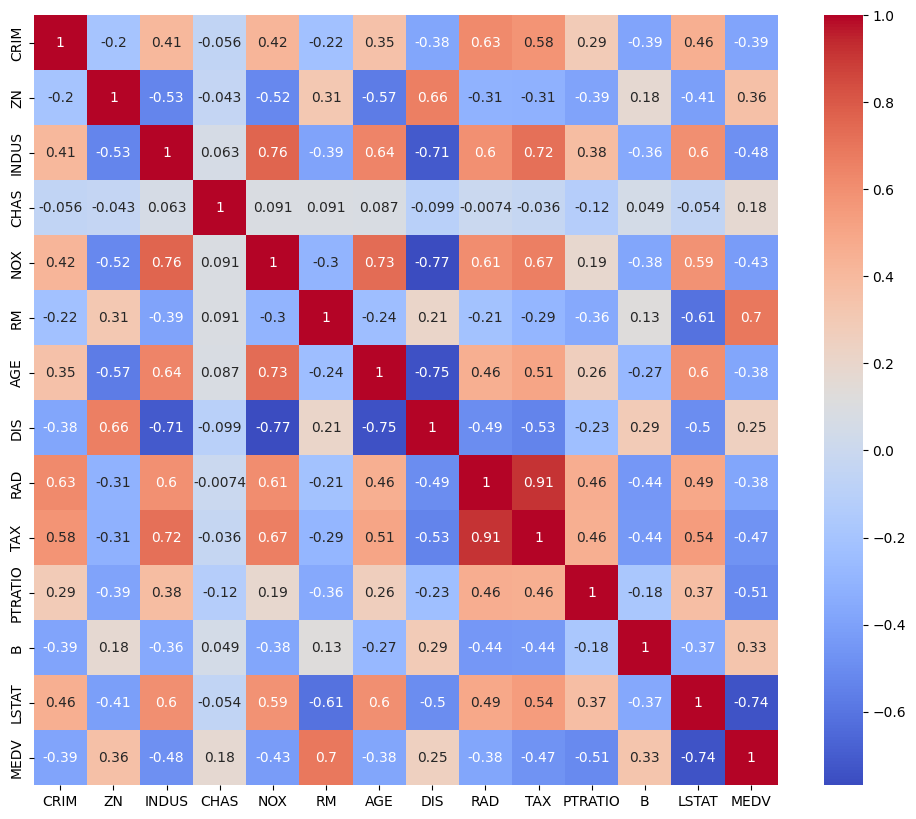

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()

##Explanation of Heatmap

**What it shows**: Each square in the heatmap represents the correlation coefficient between two variables. The diagonal line (from top-left to bottom-right) shows the correlation of a variable with itself, which is always 1.

**Color Intensity and Value:** The colors indicate the strength and direction of the correlation:<br><br>
**Warm colors (reds):** Indicate a strong positive correlation. This means that as one variable increases, the other tends to increase as well.<br><br>
**Cool colors (blues):** Indicate a strong negative correlation. This means that as one variable increases, the other tends to decrease.
White/light colors (around 0): Indicate a weak or no linear correlation between the variables.

## Insights from the Correlation Heatmap

- **RM (rooms)** has a strong positive correlation (~0.69) with house prices, meaning homes with more rooms tend to be more expensive.

- **LSTAT** shows a strong negative correlation (~−0.74), indicating that areas with a higher percentage of lower-income population generally have lower house prices.

- **PTRATIO** (~−0.51) also negatively affects prices, suggesting that higher student-to-teacher ratios may be linked to less desirable locations.

- **CRIM, NOX, and INDUS** have moderate negative correlations, implying that higher crime, pollution, and industrial presence reduce property values.

- **RAD and TAX** are highly correlated (~0.91), meaning better highway access often comes with higher taxes.

- **DIS** has a weak positive correlation (~0.25) with price, so proximity to job centers has some influence but not a major one.

##NEGATIVE CORRELATIONS

- **DIS** : This has negative correlations with  INDUS, NOX, AGE.

##NEURAL CORRELATIONS

- **CHAS** : This parameter doesnt affect any other parameter directly.



##Ploting Graph for RM and MEDV

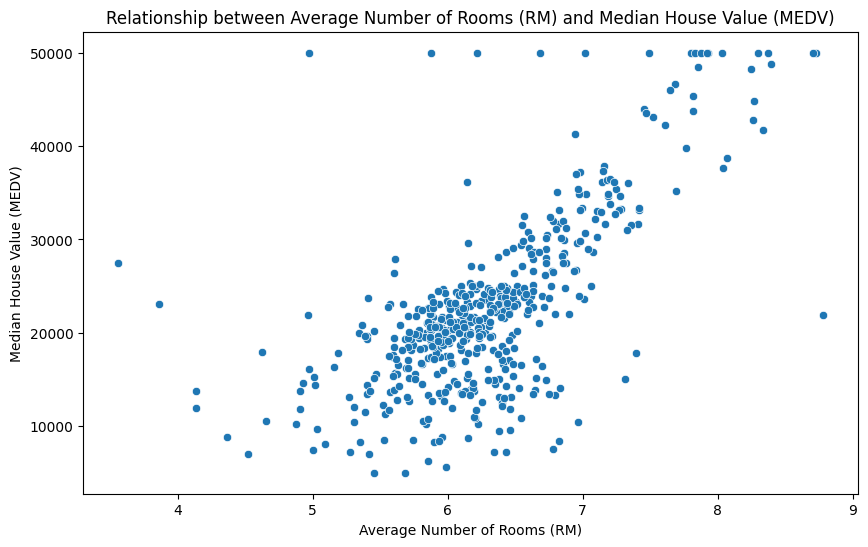

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='RM', y='MEDV', data=df)
plt.title('Relationship between Average Number of Rooms (RM) and Median House Value (MEDV)')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Value (MEDV)')

plt.show()

##Insight from MEDV vs RM

  We can clearly see the linear nature of the data points. They are majorly congested in the center with the Average number of Rooms ranging from 5 - 7 and the MEDV randing from 10,000 - 30,000. As the rooms go up the prices to, which is commonly observed.

##Ploting Graph for LSTAT and MEDV

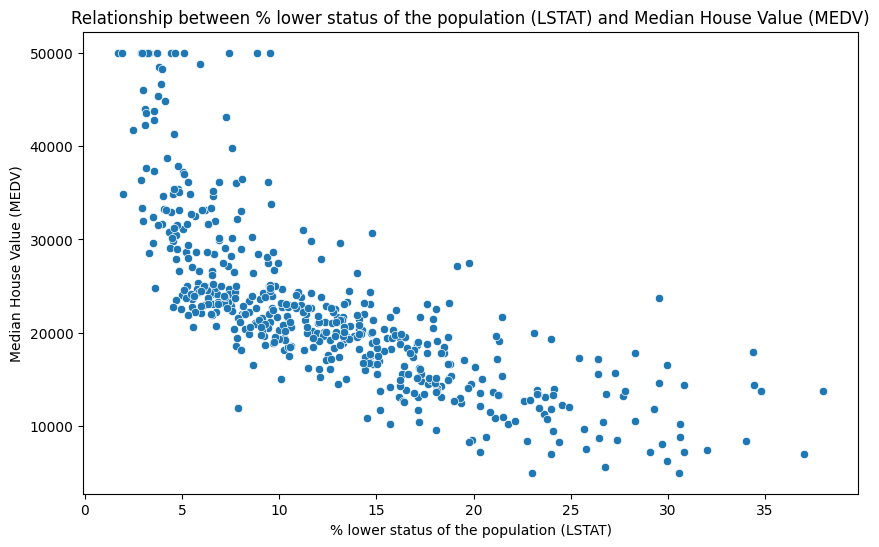

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='LSTAT', y='MEDV', data=df)
plt.title('Relationship between % lower status of the population (LSTAT) and Median House Value (MEDV)')
plt.xlabel('% lower status of the population (LSTAT)')
plt.ylabel('Median House Value (MEDV)')

plt.show()

## Insight from LSTAT and MEDV Scatter Plot

The scatter plot shows a clear negative relationship between **LSTAT** and **MEDV** — as the percentage of lower-income population increases, house prices drop.

The pattern isn’t perfectly linear; prices fall sharply at lower LSTAT values and then level off slightly at higher values. This suggests that socio-economic conditions have a strong impact on property prices.

##Ploting graph for PTRATIO and MEDV

<Figure size 1000x600 with 0 Axes>

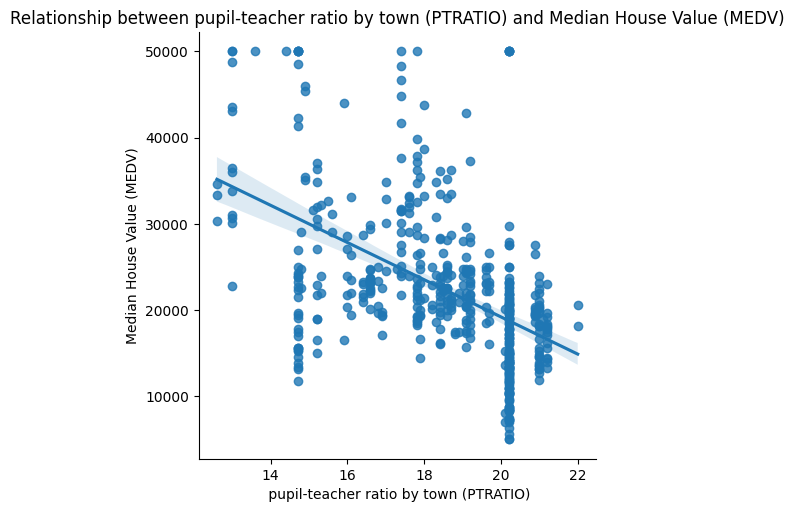

In [19]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=df, x="PTRATIO", y="MEDV")
plt.title('Relationship between pupil-teacher ratio by town (PTRATIO) and Median House Value (MEDV)')
plt.xlabel(' pupil-teacher ratio by town (PTRATIO)')
plt.ylabel('Median House Value (MEDV)')

plt.show()

## Insight from PTRATIO and MEDV lmplot

The lmplot shows a negative relationship between **PTRATIO** and **MEDV** — as the pupil-teacher ratio increases, house prices tend to decrease.

This suggests that areas with more students per teacher may be less desirable. The spread of points also shows that prices can still vary for similar PTRATIO values.

##Graph of CRIM, NOX, INDUS with MEDV

<Figure size 1000x600 with 0 Axes>

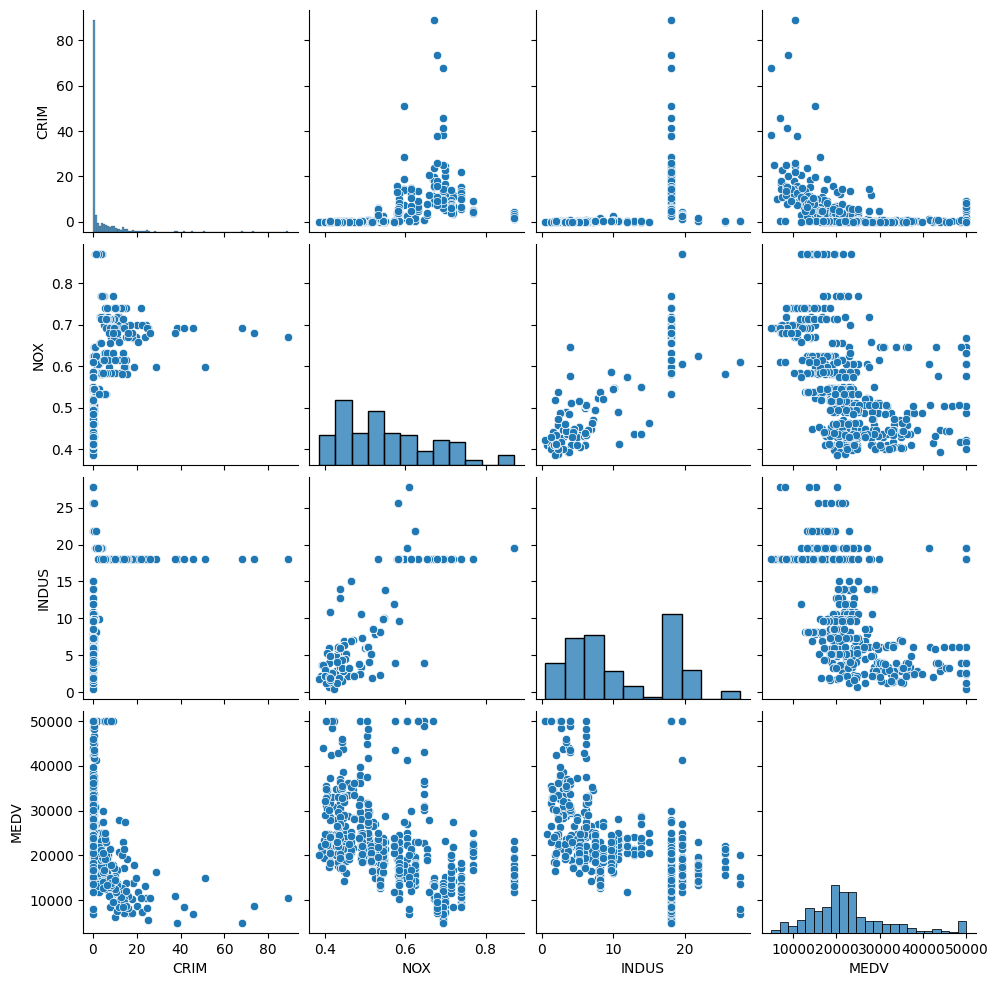

In [20]:
plt.figure(figsize=(10, 6))
sns.pairplot(df[['CRIM','NOX','INDUS','MEDV']], kind='scatter')



## Insight from Pairplot (CRIM, NOX, INDUS vs MEDV)

The plot shows a clear negative trend between **CRIM** and **MEDV** — as crime rates increase, house prices drop. The spread is wider at lower crime levels but prices fall noticeably at higher values.

For **NOX**, higher pollution levels correspond to lower house prices, showing that environmental quality directly affects property value.

Similarly, **INDUS** also shows a negative relationship with **MEDV** — areas with more industrial activity tend to have cheaper houses.

Overall, higher crime, pollution, and industrial presence are all linked to lower property prices, making these areas less desirable.

##Graph of RAD and TAX


<Figure size 1000x600 with 0 Axes>

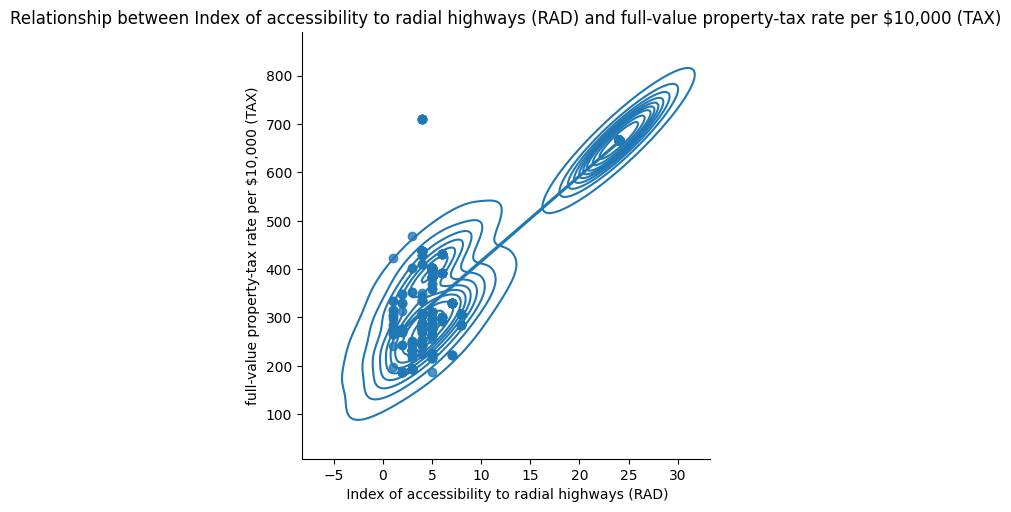

In [21]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=df, x="RAD", y="TAX")
sns.kdeplot(data=df, x="RAD", y="TAX", fill=False)
plt.title('Relationship between Index of accessibility to radial highways (RAD) and full-value property-tax rate per $10,000 (TAX)')
plt.xlabel(' Index of accessibility to radial highways (RAD)')
plt.ylabel('full-value property-tax rate per $10,000 (TAX)')

plt.show()

## Insight from RAD and TAX lmplot and kdeplot

The combined `lmplot` and `kdeplot` for **RAD** (index of accessibility to radial highways) and **TAX** (full-value property-tax rate) clearly reveal a **very strong positive linear correlation**. The upward-sloping regression line from the `lmplot` indicates that as accessibility to radial highways increases, the property tax rate tends to rise significantly. The `kdeplot` further highlights the density of data points along this strong positive trend, confirming that these two variables are highly correlated. This suggests that properties with better highway access are generally in areas with higher property tax rates, likely reflecting increased property values or better public services in such locations.

##Graph of DIS and MEDV


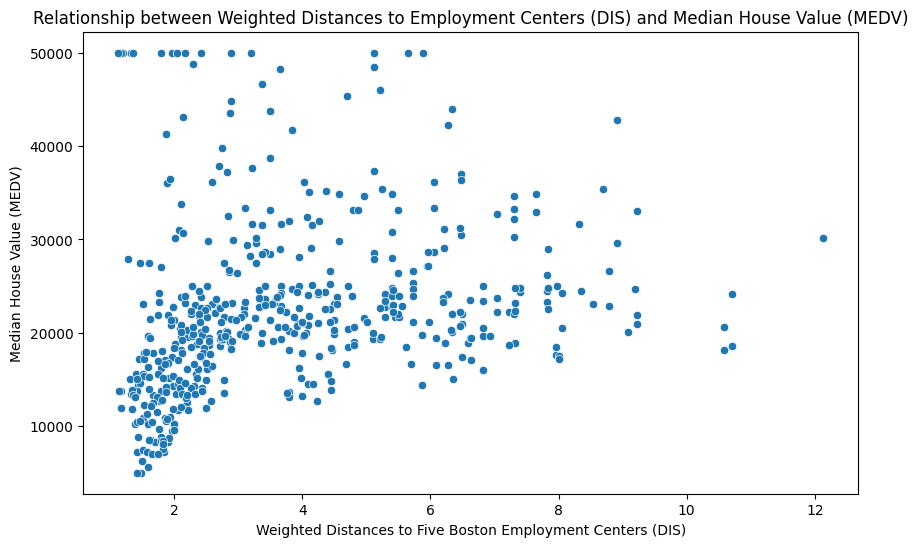

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='DIS', y='MEDV', data=df)
plt.title('Relationship between Weighted Distances to Employment Centers (DIS) and Median House Value (MEDV)')
plt.xlabel('Weighted Distances to Five Boston Employment Centers (DIS)')
plt.ylabel('Median House Value (MEDV)')

plt.show()

## Insight from DIS and MEDV Scatter Plot

The scatter plot shows a weak positive relationship between **DIS** and **MEDV**. As distance from employment centers increases, house prices seem to rise slightly, but the trend isn’t very strong.

The points are quite spread out, especially at higher distances, which suggests that distance alone doesn’t have a major impact on price. Other factors likely play a bigger role in determining house values.

## Graph of DIS vs INDUS

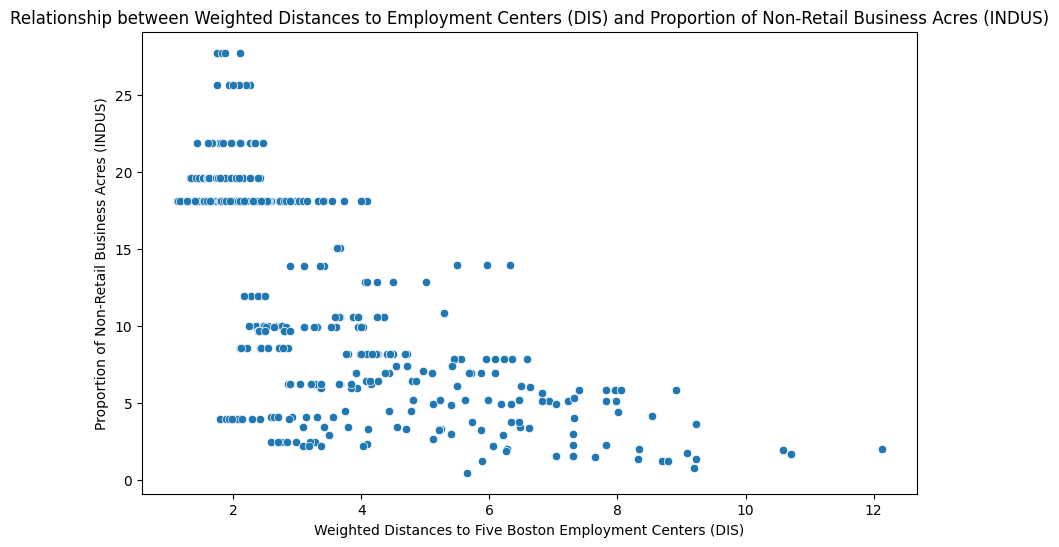

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='DIS', y='INDUS', data=df)
plt.title('Relationship between Weighted Distances to Employment Centers (DIS) and Proportion of Non-Retail Business Acres (INDUS)')
plt.xlabel('Weighted Distances to Five Boston Employment Centers (DIS)')

plt.ylabel('Proportion of Non-Retail Business Acres (INDUS)')
plt.show()

## Insight from DIS vs INDUS Scatter Plot

The scatter plot for **DIS** (weighted distances to five Boston employment centers) and **INDUS** (proportion of non-retail business acres per town) shows a **negative correlation**. As the distance to employment centers increases, the proportion of non-retail business acres tends to decrease. This indicates that industrial and commercial areas are generally located closer to employment centers, while areas further away are more residential or less developed commercially.

## Graph of DIS vs NOX

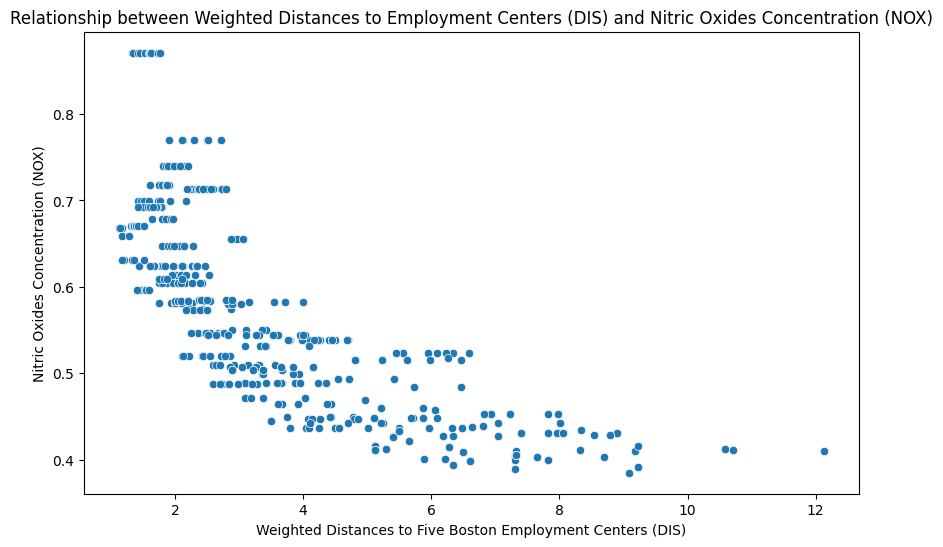

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='DIS', y='NOX', data=df)
plt.title('Relationship between Weighted Distances to Employment Centers (DIS) and Nitric Oxides Concentration (NOX)')
plt.xlabel('Weighted Distances to Five Boston Employment Centers (DIS)')

plt.ylabel('Nitric Oxides Concentration (NOX)')
plt.show()

## Insight from DIS vs NOX Scatter Plot

The scatter plot for **DIS** (weighted distances to five Boston employment centers) and **NOX** (nitric oxides concentration) reveals a **negative correlation**. As the distance from employment centers increases, the concentration of nitric oxides tends to decrease. This suggests that areas closer to employment centers, which are often more urban and industrial, have higher air pollution (NOX) levels compared to more distant, possibly suburban or rural areas.

## Graph of DIS vs AGE

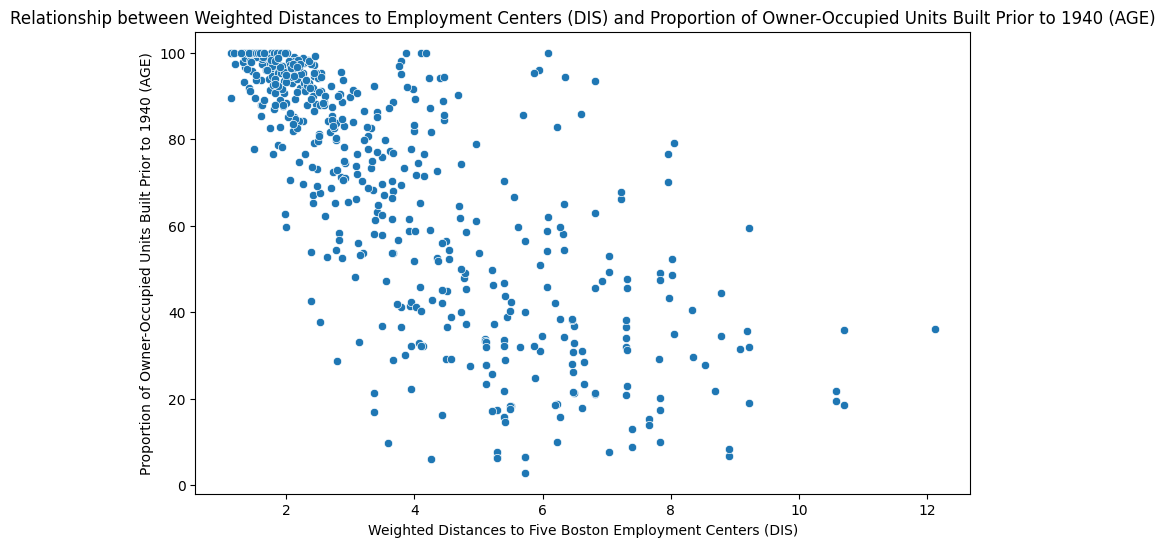

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='DIS', y='AGE', data=df)
plt.title('Relationship between Weighted Distances to Employment Centers (DIS) and Proportion of Owner-Occupied Units Built Prior to 1940 (AGE)')
plt.xlabel('Weighted Distances to Five Boston Employment Centers (DIS)')

plt.ylabel('Proportion of Owner-Occupied Units Built Prior to 1940 (AGE)')
plt.show()

## Insight from DIS vs AGE Scatter Plot

The scatter plot for **DIS** (weighted distances to five Boston employment centers) and **AGE** (proportion of owner-occupied units built prior to 1940) indicates a **negative correlation**. This means that as the distance to employment centers increases, the proportion of older, owner-occupied units (built prior to 1940) tends to decrease. This could suggest that older housing stock is more concentrated in areas closer to the urban core and employment hubs, while newer developments might be located further out.